<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/concurrence_entanglement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

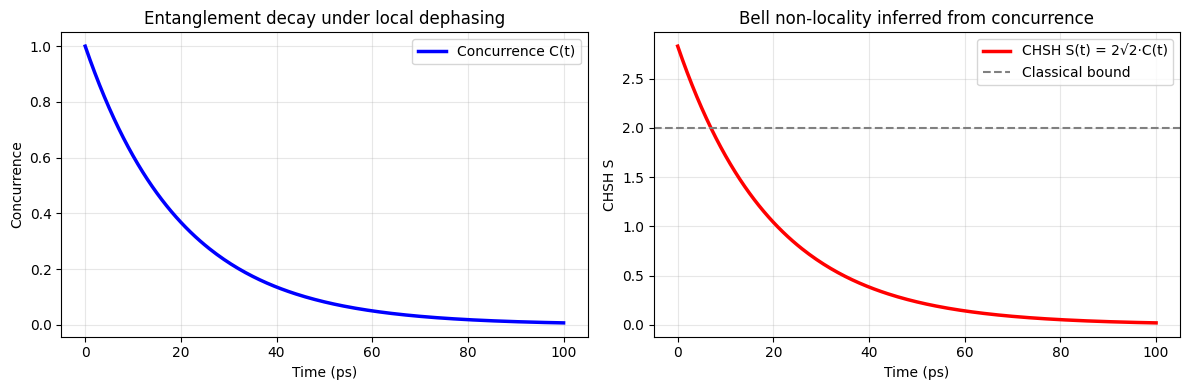

=== نتائج v18.0 (تبديد محلي على أليس, E_ext=0.5) ===
Concurrence at t=0 : 1.000000 (يجب 1)
CHSH inferred at t=0: 2.828427 (يجب ≈2.828)
Time to cross classical bound (S=2): 7.0 ps


In [5]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# ============================================================
# 1. إعدادات المحاكاة
# ============================================================
# حالة Bell الابتدائية |Φ+⟩
psi_bell = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
rho0 = np.outer(psi_bell, psi_bell)

# معاملات التبديد (σz على الكيوبت الأول فقط)
gamma0 = 5e10            # rad/s
E_ext = 0.5
gamma_eff = gamma0 * E_ext

sz = np.array([[1,0],[0,-1]], dtype=complex)
I = np.eye(2, dtype=complex)
L = np.sqrt(gamma_eff) * np.kron(sz, I)   # مؤثر ليندبلاد

# زمن المحاكاة
t_max = 100e-12          # 100 ps
dt = 0.5e-12
t_arr = np.arange(0, t_max + dt, dt)

# ============================================================
# 2. بناء الليوفيليان (بدون هاميلتوني)
# ============================================================
def build_liouvillian(L_list):
    dim = 4
    Id = np.eye(dim, dtype=complex)
    Lv = np.zeros((dim*dim, dim*dim), dtype=complex)
    for Lk in L_list:
        Lk_dag = Lk.conj().T
        Lv += np.kron(Lk, Lk.conj())
        Lv += -0.5 * (np.kron(Lk_dag @ Lk, Id) + np.kron(Id, (Lk_dag @ Lk).T))
    return Lv

Liou = build_liouvillian([L])
prop = expm(Liou * dt)

# ============================================================
# 3. التطور الزمني
# ============================================================
rhos = []
rho = rho0.copy()
for _ in range(len(t_arr)):
    rhos.append(rho.copy())
    rho_vec = prop @ rho.flatten('C')
    rho = rho_vec.reshape(4,4)
    rho = 0.5 * (rho + rho.conj().T)
    rho /= np.trace(rho).real

# ============================================================
# 4. حساب Concurrence
# ============================================================
def concurrence(rho):
    # مصفوفة Y⊗Y
    sy = np.array([[0,-1j],[1j,0]], dtype=complex)
    YY = np.kron(sy, sy)
    R = rho @ (YY @ rho.conj() @ YY)
    evals = np.linalg.eigvals(R)
    evals = np.sqrt(np.maximum(0.0, np.real(evals)))
    evals.sort()
    return max(0.0, evals[3] - evals[2] - evals[1] - evals[0])

conc_vals = [concurrence(r) for r in rhos]

# ============================================================
# 5. استنتاج CHSH تحليلياً (S = 2√2 * C)
# ============================================================
chsh_vals = [2*np.sqrt(2) * c for c in conc_vals]

# تحويل القوائم إلى مصفوفات numpy لتجنب خطأ المقارنة
chsh_vals = np.array(chsh_vals)
conc_vals = np.array(conc_vals)

# ============================================================
# 6. الرسوم البيانية
# ============================================================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(t_arr*1e12, conc_vals, 'b-', lw=2.5, label='Concurrence C(t)')
plt.xlabel('Time (ps)')
plt.ylabel('Concurrence')
plt.title('Entanglement decay under local dephasing')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
plt.plot(t_arr*1e12, chsh_vals, 'r-', lw=2.5, label='CHSH S(t) = 2√2·C(t)')
plt.axhline(2, color='gray', ls='--', lw=1.5, label='Classical bound')
plt.xlabel('Time (ps)')
plt.ylabel('CHSH S')
plt.title('Bell non-locality inferred from concurrence')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 7. طباعة النتائج
# ============================================================
print("=== نتائج v18.0 (تبديد محلي على أليس, E_ext=0.5) ===")
print(f"Concurrence at t=0 : {conc_vals[0]:.6f} (يجب 1)")
print(f"CHSH inferred at t=0: {chsh_vals[0]:.6f} (يجب ≈2.828)")

# حساب وقت عبور الحد الكلاسيكي (أول مؤشر يكون S < 2)
cross_idx = np.argmax(chsh_vals < 2)
if cross_idx > 0:
    cross_time = t_arr[cross_idx] * 1e12
    print(f"Time to cross classical bound (S=2): {cross_time:.1f} ps")
else:
    print("CHSH remains above 2 for entire simulation time.")